# Vaje 1: Uvod — orodja, numpy in postopek strojnega učenja

Cilji današnjih vaj:
- izvedeti, kako bodo potekale vaje in katera orodja bomo uporabljali,
- osvežiti (ali spoznati) **numpy**, na katerem temelji skoraj vse, kar bomo počeli,
- ponoviti **postopek strojnega učenja** in pravilno **eksperimentalno ovrednotenje** (učna, validacijska in testna množica, prečno preverjanje),
- na podobnih podatkih videti razliko med **regresijo** in **klasifikacijo**,

## 0. O vajah (~5 min)

### Kako bodo potekale vaje

Letos bodo vaje potekale nekoliko drugače kot v preteklih letih:

1. Na vajah pogledamo rešitve vaj iz prejšnjega tedna, gremo čez novo snov na praktičnih primerih, si pogledamo ključne dele implementacije.
2. Naloge, označene z **Za doma**, rešite sami doma. Rešitve objavim po vajah.
3. Po vajah je v spletni učilnici **mini kviz**, s katerim preverite, ali kodo razumete in date povratno informacijo, da ste vaje rešili. Ti mini kvizi se ne ocenjujejo.

Vaje so priprava na **domače naloge**. Vsaka domača naloga ima dva dela: v prvem doma implementirate metode, v drugem pa to implementacijo uporabite v računalniški učilnici (brez UI) za odgovarjanje na vprašanja (**kviz**).

### Orodja

| Sklop | Orodja |
|---|---|
| ves čas | Python, **numpy**, **matplotlib** |
| Globoko učenje | **PyTorch** |
| Grafi in strukturirani podatki | **networkx**, PyTorch |
| Strojno učenje in diskretna optimizacija | **pymoo**, **SRToolkit**, PyTorch |

Knjižnico scikit-learn bomo uporabljali le občasno kot pomožno orodje.

### Namestitev

Priporočam ločeno okolje, npr. s condo:

```bash
conda create -n nsu python=3.12
conda activate nsu
pip install numpy matplotlib jupyter torch networkx pymoo symbolic-regression-toolkit
```

Za vaje zadošča različica PyTorch za CPU. Če imate grafično kartico NVIDIA, si ukaz za namestitev izberite na [pytorch.org](https://pytorch.org/get-started/locally/). Če lokalna namestitev ne gre, lahko uporabite [Google Colab](https://colab.research.google.com/), kjer so te knjižnice večinoma že nameščene.

Spodnja celica preveri, ali imate vse potrebno.

In [1]:
import importlib

for paket in ["numpy", "matplotlib", "torch", "networkx", "pymoo", "SRToolkit"]:
    try:
        modul = importlib.import_module(paket)
        print(f"{paket:12s} OK  {getattr(modul, '__version__', '')}")
    except ImportError:
        print(f"{paket:12s} MANJKA")

numpy        OK  2.5.3
matplotlib   OK  3.11.2
torch        OK  2.14.1+cu130
networkx     OK  3.7
pymoo        OK  0.6.2
SRToolkit    OK  1.6.0


## 1. Numpy

Numpy je osnovna knjižnica za delo s tabelami v Pythonu. Operacije se izvajajo **vektorizirano**, torej nad celo matriko/vektorjem. PyTorch tenzorji delujejo skoraj enako, zato se splača numpy dobro poznati.

### Podatki kot tabela

Vzemimo primer kartice zvestobe s predavanj. Vsaka vrstica tabele $X$ je en primer, vsak stolpec ena napovedna spremenljivka.

In [2]:
import numpy as np

# Vhodi: prihodki (EUR/mesec), starost (leta), spol (0 = M, 1 = Ž)
X = np.array([[1890, 32, 1],
              [1200, 48, 0],
              [ 900, 63, 1]], dtype=float)

# Cilj za regresijo: poraba v naslednjih 12 mesecih (EUR/leto)
y_reg = np.array([18200, 8900, 9200], dtype=float)
# Cilj za klasifikacijo: visoka poraba (vsaj 9000 EUR) da/ne
y_clf = (y_reg >= 9000).astype(int)

print("Oblika X:", X.shape, " tip:", X.dtype)   # (n, p)
print("Oblika y:", y_reg.shape)                 # (n,)
print("y_clf:", y_clf)

Oblika X: (3, 3)  tip: float64
Oblika y: (3,)
y_clf: [1 0 1]


### Indeksiranje

Poleg običajnega indeksiranja numpy podpira še **logične maske** in **indeksiranje z vektorjem/matriko indeksov**. Slednje bomo uporabljali pri delitvi podatkov na učno in testno množico.

In [3]:
print(X[0])          # prvi primer (vrstica)
print(X[:, 1])       # starosti vseh primerov (stolpec)
print(X[1:, :2])     # rezina: primeri od drugega naprej, prva dva stolpca

maska = X[:, 1] > 40           # logična maska, oblika (n,)
print(maska)
print(X[maska])                # samo primeri, starejši od 40 let

idx = np.array([2, 0])         # polje indeksov
print(X[idx], y_reg[idx])      # izberemo iste primere v X in y

[1.89e+03 3.20e+01 1.00e+00]
[32. 48. 63.]
[[1200.   48.]
 [ 900.   63.]]
[False  True  True]
[[1.2e+03 4.8e+01 0.0e+00]
 [9.0e+02 6.3e+01 1.0e+00]]
[[9.00e+02 6.30e+01 1.00e+00]
 [1.89e+03 3.20e+01 1.00e+00]] [ 9200. 18200.]


### Agregacije po osi in razširjanje (broadcasting)

Argument `axis` pove, **po kateri osi agregiramo** (katera os pri agregaciji izgine). `axis=0` torej povpreči po vrsticah in vrne en rezultat na stolpec.

Pri operacijah med matrikami različnih oblik numpy oblike primerja z desne. Os velikosti 1 (ali manjkajoča os) se razširi na velikost druge osi. Tako lahko npr. od tabele velikosti $(n, p)$ odštejemo vektor povprečij velikosti $(p,)$ brez zanke.

In [4]:
print(X.mean(axis=0))    # povprečje vsakega stolpca, oblika (p,)
print(X.mean(axis=1))    # povprečje vsake vrstice, oblika (n,)

# Standardizacija: (n, p) - (p,) -> (n, p)
mu = X.mean(axis=0)
sigma = X.std(axis=0)
Z = (X - mu) / sigma
print(Z.round(2))
print(Z.mean(axis=0).round(6), Z.std(axis=0))

[1.33000000e+03 4.76666667e+01 6.66666667e-01]
[641.         416.         321.33333333]
[[ 1.35 -1.24  0.71]
 [-0.31  0.03 -1.41]
 [-1.04  1.21  0.71]]
[0. 0. 0.] [1. 1. 1.]


In [5]:
# Pogost trik: z None (ali np.newaxis) dodamo os in izračunamo vse pare naenkrat.
a = np.arange(3)                   # (3,)
b = np.arange(4)                   # (4,)
razlike = a[:, None] - b[None, :]  # (3, 1) - (1, 4) -> (3, 4)
print(razlike)

[[ 0 -1 -2 -3]
 [ 1  0 -1 -2]
 [ 2  1  0 -1]]


### Zakaj vektorizacija?

In [6]:
import time

rng = np.random.default_rng(0)
v = rng.normal(size=1_000_000)

def vsota_kvadratov_zanka(v):
    s = 0.0
    for x in v:
        s += x * x
    return s

t = time.perf_counter(); vsota_kvadratov_zanka(v); t_zanka = time.perf_counter() - t
t = time.perf_counter(); np.sum(v ** 2);           t_numpy = time.perf_counter() - t
print(f"zanka: {t_zanka:.4f} s, numpy: {t_numpy:.4f} s, pohitritev: {t_zanka / t_numpy:.0f}x")

zanka: 0.1958 s, numpy: 0.0048 s, pohitritev: 40x


### Naključnost in manjkajoče vrednosti

Za ponovljive poskuse vedno ustvarimo generator z določenim semenom naključnosti (`np.random.default_rng(seme)`) in ga podajamo funkcijam, ki potrebujejo naključnost.

Manjkajoče vrednosti v numeričnih poljih označujemo z `np.nan`. Pozor: `np.nan == np.nan` vrne `False`, zato manjkajoče vrednosti iščemo z `np.isnan`.

In [7]:
rng = np.random.default_rng(42)
print(rng.permutation(10))         # naključna permutacija indeksov 0..9
print(rng.normal(size=(2, 3)))

x = np.array([1.0, np.nan, 3.0])
print(x.mean(), np.nanmean(x))     # nan se "razširi"; nanmean ga izpusti
print(np.isnan(x), np.nan == np.nan)

[5 6 0 7 3 2 4 9 1 8]
[[ 0.1278404  -0.31624259 -0.01680116]
 [-0.85304393  0.87939797  0.77779194]]
nan 2.0
[False  True False] False


### ✏️ Za doma — Naloga 1: čiščenje podatkov v numpy

V datoteki `podatki.csv` so podatki za binarno klasifikacijo s 500 primeri: numerične spremenljivke `X1`, `X2`, `X3`, `X5`, `X6`, kategorična spremenljivka `X4` (`bike`, `car`, `train`) in cilj `Y`. Nekatere vrednosti manjkajo. Spodnja funkcija podatke naloži (manjkajoče numerične vrednosti so `nan`, manjkajoče vrednosti `X4` pa prazen niz `""`).

Pri vseh nalogah se izogibajte zankam po vrsticah.

**1.1** Izpišite število primerov in spremenljivk ter število in delež manjkajočih vrednosti v vsakem stolpcu (tudi v `X4`).
Namig: `np.isnan`, `sum(axis=0)`.

**1.2** Odstranite stolpce, v katerih manjka več kot 20 % vrednosti. V preostalih numeričnih stolpcih manjkajoče vrednosti nadomestite s povprečjem stolpca, v `X4` pa z najpogostejšo vrednostjo.
Namig: `np.nanmean(..., axis=0)`, `np.where`, `np.unique(..., return_counts=True)`.

**1.3** Kategorično spremenljivko `X4` zakodirajte z **one-hot** kodiranjem: vsaka kategorija dobi svoj stolpec z vrednostjo 1, če ima primer to kategorijo, in 0 sicer.

**1.4** Sestavite končno tabelo `X_koncna` (numerični stolpci in one-hot stolpci), izpišite njeno obliko in preverite, da ne vsebuje manjkajočih vrednosti.
Namig: `np.column_stack` ali `np.hstack`.

*Opomba:* tu povprečja in najpogostejšo vrednost računamo na vseh podatkih. Zakaj to ni povsem pravilno, bomo videli v razdelku 2.

In [8]:
def nalozi_podatki_csv(pot="podatki.csv"):
    # Vse preberemo kot nize, nato numerične stolpce pretvorimo v float.
    surovo = np.genfromtxt(pot, delimiter=",", dtype=str, skip_header=1, encoding="utf-8")
    imena_num = ["X1", "X2", "X3", "X5", "X6"]
    num = surovo[:, [1, 2, 3, 5, 6]]
    num = np.char.strip(num, "“”\"")            # en zapis v X6 je v "pametnih" narekovajih
    num = np.where(num == "", "nan", num).astype(float)
    x4 = surovo[:, 4]
    y = surovo[:, 7].astype(int)
    return num, imena_num, x4, y

X_num, imena_num, x4, y_podatki = nalozi_podatki_csv()
print(X_num[:5])
print(x4[:5], y_podatki[:5])

[[ 4.52553335e-01  6.91137560e+01 -2.55855469e+00  2.32101628e+01
              nan]
 [ 8.65373115e-01  3.98552858e+01 -7.27901077e-01  2.41367360e+01
              nan]
 [            nan  8.23217690e+01 -6.09281950e+00  7.04413308e+01
   9.37875791e+05]
 [ 5.68115551e-01  8.26381107e+01 -8.24887744e+00             nan
   1.97308829e+05]
 [ 9.36620941e-01  3.44601518e+01 -9.57768403e+00  4.67731212e+01
   2.53860317e+05]]
['car' 'bike' 'bike' 'car' ''] [1 0 0 1 0]


In [ ]:
# 1.1
# TODO

In [ ]:
# 1.2
# TODO

In [ ]:
# 1.3
# TODO

In [ ]:
# 1.4
# TODO

## 2. Postopek strojnega učenja

Isti postopek bomo uporabljali na vseh vajah in domačih nalogah, ne glede na to, ali učimo kNN, nevronsko mrežo ali model za simbolno regresijo.

```
                 ┌─► S_train ─► priprava podatkov (učenje) ─► model m = A(S_train; λ)
S ─ razdelitev ──┤                                                
  po indeksih    ├─► S_val ───► priprava (le uporaba) ─► Error(m, S_val) ─► izbira λ (in A)
                 └─► S_test ──► priprava (le uporaba) ─► Error(m, S_test): ENKRAT, na koncu
```

**Pravila, ki se jih držimo:**

1. Podatke razdelimo **po indeksih**, naključno in z nastavljenim semenom naključnosti. Povezane primere (npr. več meritev istega pacienta) damo v isto delitev, pri časovnih podatkih pa upoštevamo čas.
2. Vse, kar se iz podatkov **nauči**, izračunamo samo na $S_{train}$: parametre modela, pa tudi povprečja za imputacijo, $\mu$ in $\sigma$ za standardizacijo, izbor spremenljivk … Na $S_{val}$ in $S_{test}$ naučeno le uporabimo.
3. **Hiperparametre** $\lambda$ (npr. število sosedov $k$, hitrost učenja, število epoh) izbiramo na $S_{val}$ ali s prečnim preverjanjem, nikoli na $S_{test}$.
4. $S_{test}$ uporabimo **enkrat**, za končno oceno. Če na njegovi podlagi kaj spreminjamo, ocena postane optimistična.
5. Rezultate je smiselno primerjati z **osnovnim modelom**: povprečjem ciljnih vrednosti pri regresiji oziroma večinskim razredom pri klasifikaciji.

Kadar je podatkov malo, namesto ene validacijske množice uporabimo **prečno preverjanje** (prosojnica s predavanj):

$$CV(\mathcal{A}, \lambda, S) = \frac{1}{K} \sum_{k=1}^{K} Error\left(\mathcal{A}(S_{-k}; \lambda), S_k\right).$$

### Podatki

Uporabljali bomo podatke o diabetesu (`podatki_regresija.csv`): 442 pacientov, 10 vhodnih spremenljivk (starost, spol, indeks telesne mase, krvni tlak in šest meritev krvnega seruma, že centriranih in skaliranih) ter ciljno spremenljivko `target`, numerično mero napredovanja bolezni po enem letu.

In [9]:
with open("podatki_regresija.csv") as f:
    imena = f.readline().strip().split(",")
D = np.genfromtxt("podatki_regresija.csv", delimiter=",", skip_header=1)
X, y = D[:, :-1], D[:, -1]
imena = imena[:-1]
print(imena)
print("X:", X.shape, " y:", y.shape)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
X: (442, 10)  y: (442,)


### Razdelitev po indeksih

In [10]:
def razdeli_indekse(n, delezi=(0.6, 0.2, 0.2), rng=None):
    # Naključno razdeli indekse 0..n-1 na paroma disjunktne učne, validacijske in testne indekse.
    rng = np.random.default_rng() if rng is None else rng
    perm = rng.permutation(n)
    n_train = int(delezi[0] * n)
    n_val = int(delezi[1] * n)
    return perm[:n_train], perm[n_train:n_train + n_val], perm[n_train + n_val:]

rng = np.random.default_rng(0)
i_train, i_val, i_test = razdeli_indekse(len(y), rng=rng)
print(len(i_train), len(i_val), len(i_test))

X_train, X_val, X_test = X[i_train], X[i_val], X[i_test]
y_train, y_val, y_test = y[i_train], y[i_val], y[i_test]

265 88 89


### Priprava podatkov: učimo na $S_{train}$, uporabimo povsod

Standardizacija ima „parametre“ $\mu$ in $\sigma$. Izračunamo jih le na učnih podatkih, nato pa z njimi transformiramo vse tri množice. Zato validacijski in testni stolpci nimajo povprečja točno 0, in tako je prav: tako se bo obnašal tudi nov podatek, ki ga ob učenju nismo videli.

In [11]:
def nauci_standardizacijo(X):
    return X.mean(axis=0), X.std(axis=0)

def standardiziraj(X, mu, sigma):
    return (X - mu) / sigma

mu, sigma = nauci_standardizacijo(X_train)        # samo učni podatki!
Z_train = standardiziraj(X_train, mu, sigma)
Z_val = standardiziraj(X_val, mu, sigma)
Z_test = standardiziraj(X_test, mu, sigma)

print("povprečja (učna):        ", Z_train.mean(axis=0).round(2))
print("povprečja (validacijska):", Z_val.mean(axis=0).round(2))

povprečja (učna):         [ 0.  0.  0. -0. -0.  0. -0.  0. -0.  0.]
povprečja (validacijska): [ 0.18 -0.02 -0.19 -0.05  0.04 -0.01  0.02 -0.02  0.07  0.02]


### ✏️ Za doma — Naloga 2: prečno preverjanje in pravilna priprava podatkov

**2.1** Napišite funkcijo `k_kratna_razdelitev(n, K, rng)`, ki naključno razdeli indekse $0, \dots, n-1$ na $K$ približno enako velikih delov in vrne seznam $K$ parov `(i_ucni, i_val)`. V $k$-tem paru so `i_val` indeksi $k$-tega dela $S_k$, `i_ucni` pa vsi ostali, $S_{-k}$. Preverite, da so validacijski deli paroma disjunktni in skupaj pokrijejo vse indekse.
Namig: `rng.permutation`, `np.array_split`, `np.concatenate`.

**2.2** Popravite čiščenje podatkov iz Naloge 1: podatke `podatki.csv` najprej razdelite na učno in testno množico (80 : 20), nato pa povprečja in najpogostejšo vrednost `X4` izračunajte le na učni množici in z njimi zapolnite manjkajoče vrednosti v obeh množicah. Napišite funkciji `nauci_imputacijo(X_num, x4)` in `imputiraj(X_num, x4, parametri)`.

In [ ]:
# 2.1
def k_kratna_razdelitev(n, K, rng):
    # TODO
    pass

In [ ]:
# 2.2
def nauci_imputacijo(X_num, x4):
    # TODO
    pass

def imputiraj(X_num, x4, parametri):
    # TODO
    pass

## 3. Regresija in klasifikacija na istih podatkih

Model je funkcija $m: \mathcal{X} \to D_Y$. Vrsta naloge je odvisna od domene cilja $D_Y$:

| | regresija | klasifikacija |
|---|---|---|
| cilj | numerična vrednost, $D_Y = \mathbb{R}$ | kategorija, npr. $D_Y = \{0, 1\}$ |
| napaka na $S$ | MSE (oz. RMSE, $R^2$) | napaka 0–1 (delež napačnih napovedi), ... |
| osnovni model | povprečje učnih ciljnih vrednosti | večinski razred učnih podatkov |

Iz istih podatkov lahko sestavimo obe nalogi, tako kot pri kartici zvestobe s predavanj (znesek porabe ali visoka poraba da/ne). Pri diabetesu napovedujemo bodisi vrednost `target` (regresija) bodisi, ali je `target` $\geq 150$, torej ali bolezen napreduje hitro (klasifikacija).

In [12]:
prag = 150
yc_train, yc_val, yc_test = [(t >= prag).astype(int) for t in (y_train, y_val, y_test)]
print("Delež pozitivnega razreda (učna):", yc_train.mean().round(3))

def mse(y, y_hat):
    return np.mean((y - y_hat) ** 2)

def r2(y, y_hat):
    return 1 - mse(y, y_hat) / np.var(y)

def napaka_01(y, y_hat):
    return np.mean(y != y_hat)

# Osnovna modela
print("Regresija, osnovni model, RMSE (val):     ", np.sqrt(mse(y_val, np.full(len(y_val), y_train.mean()))).round(2))
vecinski = np.bincount(yc_train).argmax()
print("Klasifikacija, osnovni model, napaka (val):", napaka_01(yc_val, np.full(len(yc_val), vecinski)).round(3))

Delež pozitivnega razreda (učna): 0.445
Regresija, osnovni model, RMSE (val):      78.87
Klasifikacija, osnovni model, napaka (val): 0.477


### Linearna regresija

Model $\hat y = \beta_0 + x^\top \beta$ dobimo z metodo najmanjših kvadratov. Tabeli $X$ dodamo stolpec enic (za $\beta_0$) in rešimo $\min_\beta \lVert X_1 \beta - y \rVert^2$.

In [13]:
def nauci_linearno_regresijo(X, y):
    X1 = np.column_stack([np.ones(len(X)), X])        # stolpec enic za presečišče
    beta, *_ = np.linalg.lstsq(X1, y, rcond=None)
    return beta

def napovej_linearno(X, beta):
    return beta[0] + X @ beta[1:]

beta = nauci_linearno_regresijo(Z_train, y_train)
y_hat = napovej_linearno(Z_val, beta)
print("Linearna regresija: RMSE (val) =", np.sqrt(mse(y_val, y_hat)).round(2), " R² (val) =", r2(y_val, y_hat).round(3))

Linearna regresija: RMSE (val) = 52.91  R² (val) = 0.55


### Metoda $k$ najbližjih sosedov

Ista metoda deluje za obe nalogi. Razlika je le v tem, kako združimo cilje $k$ najbližjih sosedov: pri regresiji jih povprečimo, pri klasifikaciji pa izberemo najbolj pogosto vrednost.

Vse razdalje izračunamo naenkrat z razširjanjem: $(m, 1, p) - (1, n, p) \to (m, n, p)$.

In [14]:
def knn_napovej(X_ucni, y_ucni, X_nov, k, naloga="regresija"):
    # Kvadrati razdalj med vsemi pari (nov primer, učni primer), oblika (m, n)
    D = ((X_nov[:, None, :] - X_ucni[None, :, :]) ** 2).sum(axis=2)
    sosedi = np.argsort(D, axis=1)[:, :k]      # indeksi k najbližjih, (m, k)
    y_sosedi = y_ucni[sosedi]                  # njihovi cilji, (m, k)
    if naloga == "regresija":
        return y_sosedi.mean(axis=1)
    # Binarna klasifikacija (razreda 0 in 1): večinsko glasovanje (pri lihem k ni neodločenih izidov)
    return (y_sosedi.mean(axis=1) > 0.5).astype(int)

print("kNN regresija,    k=11: RMSE (val) =",
      np.sqrt(mse(y_val, knn_napovej(Z_train, y_train, Z_val, 11))).round(2))
print("kNN klasifikacija, k=11: napaka (val) =",
      napaka_01(yc_val, knn_napovej(Z_train, yc_train, Z_val, 11, "klasifikacija")).round(3))

kNN regresija,    k=11: RMSE (val) = 53.16
kNN klasifikacija, k=11: napaka (val) = 0.25


### Izbira hiperparametra $k$ na validacijski množici

Narišimo učno in validacijsko napako v odvisnosti od $k$. Pri $k = 1$ je učna napaka 0 (vsak učni primer je sam svoj najbližji sosed), validacijska pa je velika: model se preveč prilega učnim podatkom.

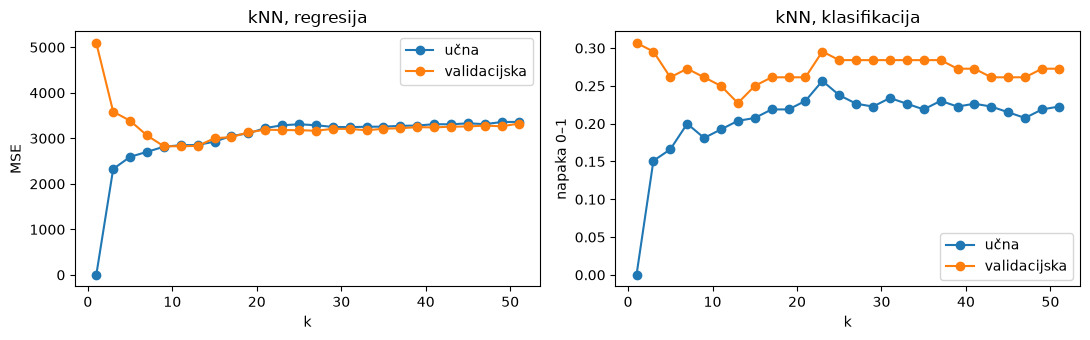

Najboljši k: regresija 9 , klasifikacija 13


In [15]:
import matplotlib.pyplot as plt

ks = np.arange(1, 52, 2)
rez = {"regresija": ([], []), "klasifikacija": ([], [])}
for k in ks:
    for naloga, yt, yv, napaka in [("regresija", y_train, y_val, mse),
                                   ("klasifikacija", yc_train, yc_val, napaka_01)]:
        rez[naloga][0].append(napaka(yt, knn_napovej(Z_train, yt, Z_train, k, naloga)))
        rez[naloga][1].append(napaka(yv, knn_napovej(Z_train, yt, Z_val, k, naloga)))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, (naloga, (n_ucna, n_val)), oznaka in zip(axes, rez.items(), ["MSE", "napaka 0–1"]):
    ax.plot(ks, n_ucna, "o-", label="učna")
    ax.plot(ks, n_val, "o-", label="validacijska")
    ax.set(title=f"kNN, {naloga}", xlabel="k", ylabel=oznaka)
    ax.legend()
plt.tight_layout()
plt.show()

k_reg = ks[np.argmin(rez["regresija"][1])]
k_clf = ks[np.argmin(rez["klasifikacija"][1])]
print("Najboljši k: regresija", k_reg, ", klasifikacija", k_clf)

Šele ko smo izbrali $k$, model ovrednotimo na testni množici, in to enkrat. Model lahko pred tem ponovno naučimo na $S_{train} \cup S_{val}$; pri tem moramo na novo izračunati tudi standardizacijo.

In [16]:
i_tv = np.concatenate([i_train, i_val])
mu_tv, sigma_tv = nauci_standardizacijo(X[i_tv])
Z_tv, Z_te = standardiziraj(X[i_tv], mu_tv, sigma_tv), standardiziraj(X_test, mu_tv, sigma_tv)
y_tv = y[i_tv]
yc_tv = (y_tv >= prag).astype(int)

print("Regresija,     kNN (k=%d): RMSE (test) = %.2f" % (k_reg, np.sqrt(mse(y_test, knn_napovej(Z_tv, y_tv, Z_te, k_reg)))))
print("Klasifikacija, kNN (k=%d): napaka (test) = %.3f" % (k_clf, napaka_01(yc_test, knn_napovej(Z_tv, yc_tv, Z_te, k_clf, "klasifikacija"))))

Regresija,     kNN (k=9): RMSE (test) = 59.40
Klasifikacija, kNN (k=13): napaka (test) = 0.247


### Past: data leakage

Kaj se zgodi, če pravilo 2 prekršimo? Sestavimo podatke, kjer ciljna vrednost **ni** odvisna od vhodov: 5000 naključnih spremenljivk in naključne oznake 0/1. Noben model ne more biti boljši od 50 % napake.

Napaka, ki jo naredimo: med vsemi podatki izberemo 20 spremenljivk, ki so najbolj korelirane s ciljem, šele nato pa podatke razdelimo na učno in testno množico.

In [17]:
rng = np.random.default_rng(1)
n_sum, p_sum = 200, 5000
X_sum = rng.normal(size=(n_sum, p_sum))
y_sum = rng.integers(0, 2, size=n_sum)        # cilj je popolnoma naključen

def izberi_spremenljivke(X, y, st=20):
    Xs = (X - X.mean(axis=0)) / X.std(axis=0)
    ys = (y - y.mean()) / y.std()
    korelacije = np.abs(Xs.T @ ys) / len(y)
    return np.argsort(korelacije)[-st:]

def napaka_poskusa(izbor_na_vseh, rng):
    i_tr, _, i_te = razdeli_indekse(n_sum, (0.7, 0.0, 0.3), rng)
    if izbor_na_vseh:
        izbrane = izberi_spremenljivke(X_sum, y_sum)               # NAROBE: vidi tudi testne cilje
    else:
        izbrane = izberi_spremenljivke(X_sum[i_tr], y_sum[i_tr])   # PRAV: le učni podatki
    napoved = knn_napovej(X_sum[i_tr][:, izbrane], y_sum[i_tr], X_sum[i_te][:, izbrane], 5, "klasifikacija")
    return napaka_01(y_sum[i_te], napoved)

# Testna množica je majhna (60 primerov), zato poskus ponovimo z 20 različnimi delitvami.
print("NAROBE: povprečna napaka (test) =", np.mean([napaka_poskusa(True, rng) for _ in range(20)]).round(3))
print("PRAV:   povprečna napaka (test) =", np.mean([napaka_poskusa(False, rng) for _ in range(20)]).round(3))

NAROBE: povprečna napaka (test) = 0.282
PRAV:   povprečna napaka (test) = 0.515


### ✏️ Za doma — Naloga 3: prečno preverjanje, regresija in klasifikacija

**3.1** Napišite funkcijo `precno_preverjanje(X, y, k, naloga, K, rng)`, ki z vašo funkcijo `k_kratna_razdelitev` izračuna $CV(\text{kNN}, k, S)$: povprečni MSE pri regresiji oziroma povprečno napako 0–1 pri klasifikaciji. Standardizacijo v vsaki delitvi naučite le na $S_{-k}$.

**3.2** S 5-kratnim prečnim preverjanjem na $S_{train} \cup S_{val}$ (spremenljivke `X[i_tv]`, `y_tv`, `yc_tv` zgoraj) izberite najboljši $k \in \{1, 3, \dots, 51\}$ za regresijo in za klasifikacijo. Ali dobite enak $k$ kot z eno validacijsko množico? Z izbranim $k$ izračunajte napako na testni množici in jo primerjajte z linearno regresijo in osnovnim modelom.

**3.3** Regresija ali klasifikacija? Za klasifikacijsko nalogo (`target` $\geq 150$) lahko namesto klasifikatorja naučimo regresijski model in njegovo napoved primerjamo s pragom: $\hat y_{clf} = \mathbf{1}(\hat y_{reg} \geq 150)$. Na testni množici primerjajte napako 0–1:
- kNN klasifikatorja,
- kNN regresije s pragom,
- linearne regresije s pragom.

Kateri pristop je boljši? Zakaj bi lahko regresijski model s pragom deloval dobro (ali slabo)?

**3.4 (dodatno)** Napaka 0–1 ne pove vsega, posebej pri neuravnoteženih razredih. V numpy izračunajte matriko zmede, preciznost in priklic za modele iz 3.3.

In [ ]:
# 3.1
def precno_preverjanje(X, y, k, naloga="regresija", K=5, rng=None):
    # TODO
    pass

In [ ]:
# 3.2
# TODO

In [ ]:
# 3.3
# TODO

In [ ]:
# 3.4 (dodatno)
# TODO

## 4. Kratek pogled v PyTorch

V sklopu o globokem učenju bomo namesto numpy uporabljali PyTorch. Dobra novica: tenzorji v PyTorch se obnašajo skoraj enako kot polja numpy, z enakim indeksiranjem, razširjanjem in operatorjem `@`.

| numpy | PyTorch |
|---|---|
| `np.array(a)` | `torch.tensor(a)` |
| `X.shape`, `X[:, 1]`, `X[maska]`, `X[idx]` | enako |
| `X.mean(axis=0)` | `X.mean(dim=0)` (deluje tudi `axis=0`) |
| `X @ W`, `X.T`, `X[:, None, :]` | enako |
| `np.random.default_rng(0)` | `torch.manual_seed(0)` ali `torch.Generator().manual_seed(0)` |
| `rng.permutation(n)` | `torch.randperm(n)` |
| `np.argsort(D, axis=1)` | `torch.argsort(D, dim=1)` (ali `torch.topk`) |
| `np.linalg.lstsq(A, b)` | `torch.linalg.lstsq(A, B)` |
| `np.column_stack`, `np.concatenate` | `torch.column_stack`, `torch.cat` |
| pretvorba | `torch.from_numpy(a)`, `t.numpy()` |

Za primer prepišimo kNN: koda je praktično enaka.

In [18]:
import torch

def knn_napovej_torch(X_ucni, y_ucni, X_nov, k, naloga="regresija"):
    D = ((X_nov[:, None, :] - X_ucni[None, :, :]) ** 2).sum(dim=2)
    sosedi = torch.argsort(D, dim=1)[:, :k]
    y_sosedi = y_ucni[sosedi]
    if naloga == "regresija":
        return y_sosedi.mean(dim=1)
    # PyTorch je glede tipov strožji: povprečja celoštevilskega tenzorja ne izračuna, zato .float()
    return (y_sosedi.float().mean(dim=1) > 0.5).long()

Zt_tv, Zt_te = torch.from_numpy(Z_tv), torch.from_numpy(Z_te)   # float64, kot v numpy
napoved_torch = knn_napovej_torch(Zt_tv, torch.from_numpy(yc_tv), Zt_te, k_clf, "klasifikacija")
napoved_numpy = knn_napovej(Z_tv, yc_tv, Z_te, k_clf, "klasifikacija")
print("Enake napovedi:", np.array_equal(napoved_torch.numpy(), napoved_numpy))

# Tudi linearna regresija z najmanjšimi kvadrati
X1 = torch.column_stack([torch.ones(len(Zt_tv), dtype=torch.float64), Zt_tv])
beta_torch = torch.linalg.lstsq(X1, torch.from_numpy(y_tv)[:, None]).solution.squeeze()
print("Enaki koeficienti:", np.allclose(beta_torch.numpy(), nauci_linearno_regresijo(Z_tv, y_tv)))

Enake napovedi: True
Enaki koeficienti: True


Kaj torej PyTorch doda? Predvsem dve stvari: **samodejno odvajanje** (autograd) in izvajanje na **grafični kartici**. Isti linearni model se lahko naučimo z gradientnim spustom, ne da bi odvode izpeljali sami. Na tem temelji učenje vseh nevronskih mrež, s katerimi bomo delali v naslednjih tednih.

In [19]:
torch.manual_seed(0)
Xt = torch.from_numpy(Z_tv).float()            # nevronske mreže običajno uporabljajo float32
yt = torch.from_numpy(y_tv).float()

w = torch.zeros(Xt.shape[1], requires_grad=True)
b = torch.zeros(1, requires_grad=True)
optimizator = torch.optim.SGD([w, b], lr=0.1)

for korak in range(1000):
    izguba = ((Xt @ w + b - yt) ** 2).mean()   # MSE
    optimizator.zero_grad()
    izguba.backward()                          # autograd izračuna odvode po w in b
    optimizator.step()                         # w <- w - lr * dL/dw

with torch.no_grad():
    y_hat_gd = (torch.from_numpy(Z_te).float() @ w + b).numpy()
print("RMSE (test), gradientni spust:   %.2f" % np.sqrt(mse(y_test, y_hat_gd)))
print("RMSE (test), najmanjši kvadrati: %.2f" % np.sqrt(mse(y_test, napovej_linearno(Z_te, nauci_linearno_regresijo(Z_tv, y_tv)))))

RMSE (test), gradientni spust:   57.12
RMSE (test), najmanjši kvadrati: 57.01
